# Implementação e Comparação do PSO
## Nome: Davi dos Santo Mattos
### DRE: 119133049

In [1]:
import numpy as np
from random import random, seed

def rosenbrock(X):
  """
  Função de Rosenbrock

  X -> Vetor de entrada

  """
  X = np.array(X)
  if X.ndim > 1:
    return np.sum(100 * (X[:, 1:] - X[:, :-1]**2)**2 + (X[:, :-1] - 1)**2, axis=1)
  else:
    return np.sum(100 * (X[1:] - X[:-1]**2)**2 + (X[:-1] - 1)**2, axis=0)


def rastrigin(X):
    """
    Função de Rastrigin

    X -> Vetor de entrada ou população
    """
    X = np.array(X)

    if X.ndim > 1:
        n = X.shape[1]
        return 10 * n + np.sum(X**2 - 10 * np.cos(2 * np.pi * X), axis=1)
    else:
        n = len(X)
        return 10 * n + np.sum(X**2 - 10 * np.cos(2 * np.pi * X))

In [2]:
def criar_populacao(dimensao, num_individuos, intervalo):
  """
  Função que cria uma população com N indivíduos.

  dimensao -> número de dimensões do problema
  n_individuos -> número de indivíduos na população
  intervalo -> intervalo de valores possíveis para cada dimensão

  """

  populacao = []
  for i in range(num_individuos):
    individuo = []
    for j in range(dimensao):
      individuo.append(np.random.uniform(intervalo[0], intervalo[1]))
    populacao.append(individuo)

  return np.array(populacao)

In [3]:
def melhor_individuo(populacao, funcao_avaliacao):
  fitness = funcao_avaliacao(populacao)
  melhor_individuo = populacao[np.argmin(fitness)]
  return melhor_individuo

#### Primeira Tentativa

In [4]:
def nuvem_particulas(tam_populacao=100, problema=rosenbrock, intervalo=[-5,10], dimensao=2, parada=10000):

  populacao = criar_populacao(dimensao, tam_populacao, intervalo)

  v = np.zeros((tam_populacao, dimensao))
  w = np.random.uniform(0,1)
  c1 = np.random.uniform(0,1)
  c2 = np.random.uniform(0,1)

  pbest = populacao.copy()
  gbest = melhor_individuo(populacao, problema)

  #geracao = 0
  chamada_de_funcao = 0

  while(chamada_de_funcao < parada):
    for i in range(tam_populacao):
      if chamada_de_funcao >= parada:
          break
      pteste = problema(populacao[i])
      chamada_de_funcao += 1
      if pteste < problema(pbest[i]):
        chamada_de_funcao+=1
        pbest[i] = populacao[i].copy()
        if pteste < problema(gbest):
          chamada_de_funcao+=1
          gbest = populacao[i].copy()
      for j in range(dimensao):
        r1 = np.random.uniform(0,1)
        r2 = np.random.uniform(0,1)

        v[i][j] = (
                w * v[i][j]
                + c1*r1*(pbest[i][j] - populacao[i][j])
                + c2*r2*(gbest[j] - populacao[i][j])
            )

      populacao[i] = populacao[i] + np.array(v[i])
    #geracao += 1
    #print(f"Geracao {geracao}\n{populacao}\n")

  print(f"Particula= [{gbest}] - f(x*) = {problema(gbest)}\nChamadas de Função = {chamada_de_funcao}")

In [5]:
nuvem_particulas(tam_populacao=100, parada=100)

Particula= [[2.38127584 5.325544  ]] - f(x*) = 13.805637769410936
Chamadas de Função = 100


#### Segunda tentativa (limitando a velocidade)

In [6]:
def pso(tam_populacao=100,problema=rosenbrock,intervalo=[-5, 10],dimensao=2,parada=10000, history=False):
    Vmax = (intervalo[1] - intervalo[0]) * 0.2  # limite de velocidade

    populacao = criar_populacao(dimensao, tam_populacao, intervalo)
    fitness   = problema(populacao)
    chamada_de_funcao = tam_populacao

    v = np.zeros((tam_populacao, dimensao))
    w = np.random.uniform(0.4, 0.9)
    c1 = 1.5
    c2 = 1.5

    #pbest
    pbest = populacao.copy()
    pbest_val = fitness.copy()

    #gbest
    idx_gbest = np.argmin(fitness)
    gbest = populacao[idx_gbest].copy()
    gbest_val = fitness[idx_gbest]

    historico = []


    while chamada_de_funcao < parada:
        for i in range(tam_populacao):

          # Atualizar velocidade
          r1 = np.random.rand(dimensao)
          r2 = np.random.rand(dimensao)
          v[i] = ( w  * v[i] + c1 * r1 * (pbest[i] - populacao[i]) + c2 * r2 * (gbest - populacao[i]) )

          v[i] = np.clip(v[i], -Vmax, Vmax)  # limita velocidade

          # Atualizar posição
          populacao[i] = np.clip(populacao[i] + v[i], intervalo[0], intervalo[1])

          # Reavaliar fitness
          fitness[i] = problema(populacao[i])
          w = 1 - chamada_de_funcao * (1 / parada)
          chamada_de_funcao += 1

          # Atualizar pBest
          if fitness[i] < pbest_val[i]:
              pbest_val[i] = fitness[i]
              pbest[i]     = populacao[i].copy()

              # Atualizar gBest
              if pbest_val[i] < gbest_val:
                  gbest_val = pbest_val[i]
                  gbest     = pbest[i].copy()
          historico.append(gbest_val)


    if history:
        return populacao, gbest, gbest_val, chamada_de_funcao, np.array(historico)
    else:
      print(f"Particula= [{gbest}] - f(x*) = {gbest_val}\nChamadas de Função = {chamada_de_funcao}")


In [7]:
pso(parada=10000)

Particula= [[1.00000103 1.00000205]] - f(x*) = 1.0670259600329597e-12
Chamadas de Função = 10000


In [8]:
pso(problema=rastrigin, intervalo=[-5.12, 5.12], dimensao=2, parada=10000)

Particula= [[-5.58309612e-10 -1.14416875e-09]] - f(x*) = 0.0
Chamadas de Função = 10000


#### Terceira tentativa (limitando a velocidade e colocando coeficientes constantes)

In [9]:
def nuvem_particulas3(tam_populacao=100,problema=rosenbrock,intervalo=[-5, 10],dimensao=2,parada=10000,history=False):
    Vmax = (intervalo[1] - intervalo[0]) * 0.2  # limite de velocidade

    populacao = criar_populacao(dimensao, tam_populacao, intervalo)
    fitness   = problema(populacao)
    chamada_de_funcao = tam_populacao
    k = 0

    v = np.zeros((tam_populacao, dimensao))
    w = np.random.uniform(0.4, 0.9)
    c1 = 2
    c2 = 2

    #pbest
    pbest = populacao.copy()
    pbest_val = fitness.copy()

    #gbest
    idx_gbest = np.argmin(fitness)
    gbest = populacao[idx_gbest].copy()
    gbest_val = fitness[idx_gbest]

    historico = []

    while chamada_de_funcao < parada:
        for i in range(tam_populacao):

            # Atualizar velocidade
            r1 = np.random.rand(dimensao)
            r2 = np.random.rand(dimensao)
            v[i] = (
                w  * v[i]
                + c1 * r1 * (pbest[i] - populacao[i])
                + c2 * r2 * (gbest    - populacao[i])
            )

            v[i] = np.clip(v[i], -Vmax, Vmax)  # limita velocidade

            # Atualizar posição
            populacao[i] = np.clip(
                populacao[i] + v[i],
                intervalo[0], intervalo[1]
            )

            # Reavaliar fitness
            fitness[i] = problema(populacao[i])
            chamada_de_funcao += 1

            # Atualizar pBest
            if fitness[i] < pbest_val[i]:
                pbest_val[i] = fitness[i]
                pbest[i]     = populacao[i].copy()

                # Atualizar gBest
                if pbest_val[i] < gbest_val:
                    gbest_val = pbest_val[i]
                    gbest     = pbest[i].copy()
            w = 0.9 - k * ((0.9 - 0.4) / parada)
            k += 1
            historico.append(gbest_val)


    if history:
        return populacao, gbest, gbest_val, chamada_de_funcao, historico
    else:
      print(f"Partícula = {gbest}")
      print(f"f(x*)     = {gbest_val}")
      print(f"Chamadas  = {chamada_de_funcao}")

In [10]:
nuvem_particulas3(tam_populacao=100, parada=10000)

Partícula = [0.99994305 0.99988587]
f(x*)     = 3.2486836035455574e-09
Chamadas  = 10000


### Curva

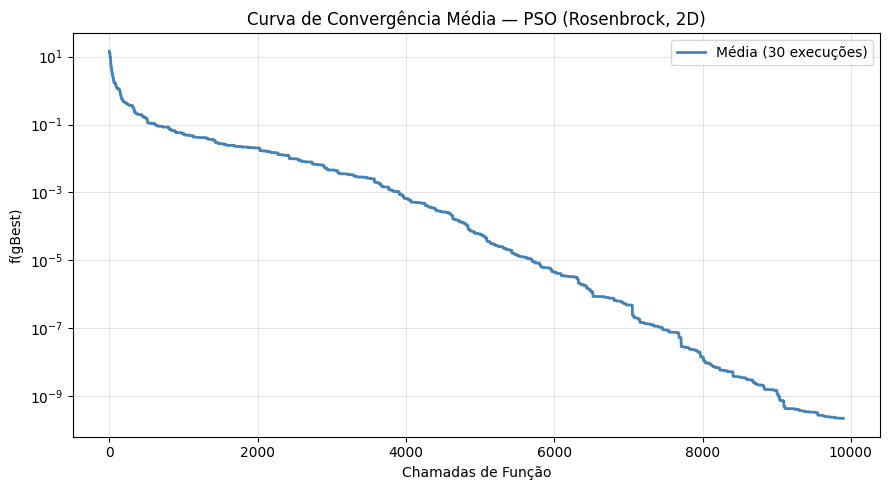

In [11]:
import numpy as np
import matplotlib.pyplot as plt

N_EXECUCOES = 30

historicos = []
for i in range(N_EXECUCOES):
    _, _, gval, _, hist = pso(
        tam_populacao=100,
        problema=rosenbrock,
        intervalo=[-5, 10],
        dimensao=2,
        parada=10000,
        history=True
    )
    historicos.append(hist)

historicos = np.array(historicos)

media  = np.mean(historicos, axis=0)

n_iteracoes = historicos.shape[1]
eixo_x = np.arange(n_iteracoes)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(eixo_x, media, color='steelblue', linewidth=2, label='Média (30 execuções)')

ax.set_xlabel('Chamadas de Função')
ax.set_ylabel('f(gBest)')
ax.set_title('Curva de Convergência Média — PSO (Rosenbrock, 2D)')
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.6)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [12]:
def curva_convergencia_media(titulo ='PSO com Kmeans', problema=rosenbrock, algoritmo=pso, intervalo=[-5, 10], dimensao=2, parada=10000, n_execucoes=30):
    historicos = []
    for i in range(n_execucoes):
        if (i+1) % 10 == 0:
            print(f"Execução {i+1}/{n_execucoes}")
        #print(f"Execução {i+1}/{n_execucoes}")
        _, _, gval, _, hist = algoritmo(
            tam_populacao=100,
            problema=problema,
            intervalo=intervalo,
            dimensao=dimensao,
            parada=parada,
            history=True
        )
        historicos.append(hist)

    historicos = np.array(historicos)

    media  = np.mean(historicos, axis=0)

    n_iteracoes = historicos.shape[1]
    eixo_x = np.arange(n_iteracoes)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(eixo_x, media, color='steelblue', linewidth=2, label=f'Média ({n_execucoes} execuções)')

    ax.set_xlabel('Chamadas de Função')
    ax.set_ylabel('f(gBest)')
    ax.set_title(f'Curva de Convergência Média — {titulo}')
    ax.legend()
    ax.grid(True, linewidth=0.4, alpha=0.6)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

Execução 10/30
Execução 20/30
Execução 30/30


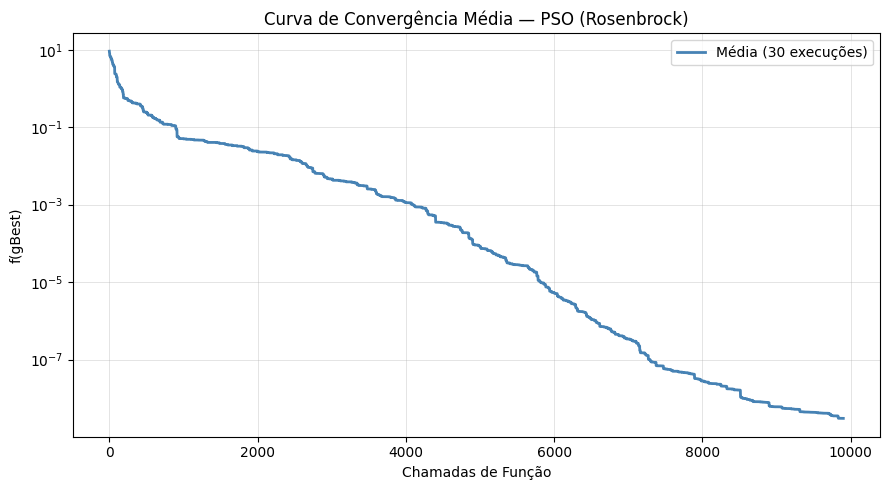

In [13]:
curva_convergencia_media(titulo='PSO (Rosenbrock)',problema=rosenbrock, algoritmo=pso, intervalo=[-5, 10], dimensao=2, parada=10000, n_execucoes=30)

Execução 10/30
Execução 20/30
Execução 30/30


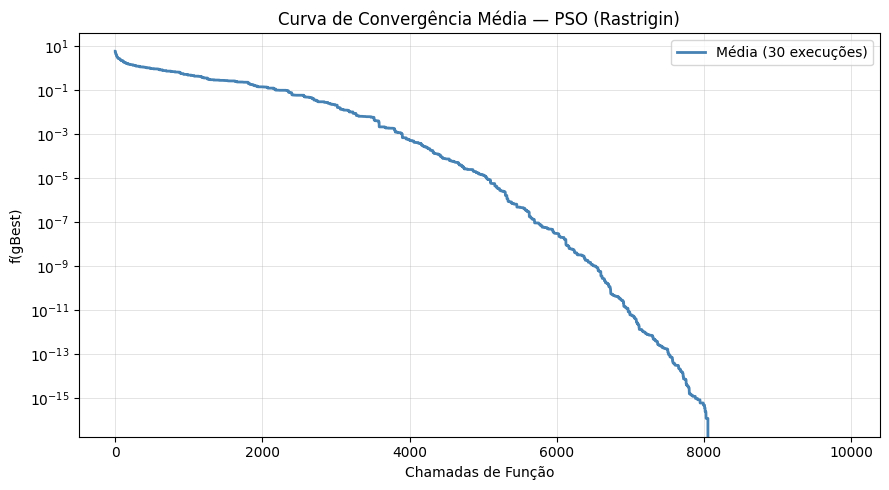

In [14]:
curva_convergencia_media(titulo='PSO (Rastrigin)',problema=rastrigin, algoritmo=pso, intervalo=[-5.12, 5.12], dimensao=2, parada=10000, n_execucoes=30)

### PSO com Kmeans

In [15]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
from sklearn.cluster import KMeans

def pso_kmeans(tam_populacao=100,problema=rosenbrock,intervalo=[-5, 10],dimensao=2,parada=10000,history=False):
    Vmax = (intervalo[1] - intervalo[0]) * 0.2  # limite de velocidade

    populacao = criar_populacao(dimensao, tam_populacao, intervalo)
    fitness   = problema(populacao)
    chamada_de_funcao = tam_populacao

    v = np.zeros((tam_populacao, dimensao))
    w = np.random.uniform(0.4, 0.9)
    c1 = 1
    c2 = 1

    #pbest
    pbest = populacao.copy()
    pbest_val = fitness.copy()

    #gbest
    idx_gbest = np.argmin(fitness)
    gbest = populacao[idx_gbest].copy()
    gbest_val = fitness[idx_gbest]

    historico = []

    while chamada_de_funcao < parada:
      if (parada/4) <= chamada_de_funcao and chamada_de_funcao < (parada/2):
        kmeans = KMeans(n_clusters=2, random_state=42)
        kmeans.fit(populacao)
        labels = kmeans.labels_
        centros = kmeans.cluster_centers_

        for cluster_id in range(2):
          idx_sub = np.where(labels == cluster_id)[0]
          if len(idx_sub) > 0:
            centroide = centros[cluster_id]
            for j in idx_sub:
              if chamada_de_funcao >= parada:
                break
              r1 = np.random.rand(dimensao)
              r2 = np.random.rand(dimensao)
              v[j] = ( w*v[j] + c1*r1*(pbest[j]-populacao[j]) + c2*r2*(centroide - populacao[j]) )
              v[j] = np.clip(v[j], -Vmax, Vmax)
              populacao[j] = np.clip(populacao[j] + v[j], intervalo[0], intervalo[1])
              fitness[j] = problema(populacao[j])
              chamada_de_funcao += 1

              if fitness[j] < pbest_val[j]:
                  pbest_val[j] = fitness[j]
                  pbest[j] = populacao[j].copy()

              # Atualizar gBest
              if pbest_val[j] < gbest_val:
                gbest_val = pbest_val[j]
                gbest = pbest[j].copy()
              historico.append(gbest_val)

      else:
        for i in range(tam_populacao):
          if chamada_de_funcao >= parada:
            break

          # Atualizar velocidade
          r1 = np.random.rand(dimensao)
          r2 = np.random.rand(dimensao)
          v[i] = (
              w  * v[i]
              + c1 * r1 * (pbest[i] - populacao[i])
              + c2 * r2 * (gbest    - populacao[i])
          )

          v[i] = np.clip(v[i], -Vmax, Vmax)  # limita velocidade

          # Atualizar posição
          populacao[i] = np.clip(
              populacao[i] + v[i],
              intervalo[0], intervalo[1]
          )

          # Reavaliar fitness
          fitness[i] = problema(populacao[i])
          chamada_de_funcao += 1

          # Atualizar pBest
          if fitness[i] < pbest_val[i]:
              pbest_val[i] = fitness[i]
              pbest[i] = populacao[i].copy()

          # Atualizar gBest
          if pbest_val[i] < gbest_val:
            gbest_val = pbest_val[i]
            gbest = pbest[i].copy()
          historico.append(gbest_val)

      w = np.random.uniform(0.4, 0.9)

    if history:
        return populacao, gbest, gbest_val, chamada_de_funcao, np.array(historico)
    else:
      print(f"Partícula = {gbest}")
      print(f"f(x*)     = {gbest_val}")
      print(f"Chamadas  = {chamada_de_funcao}")

Execução 10/30
Execução 20/30
Execução 30/30


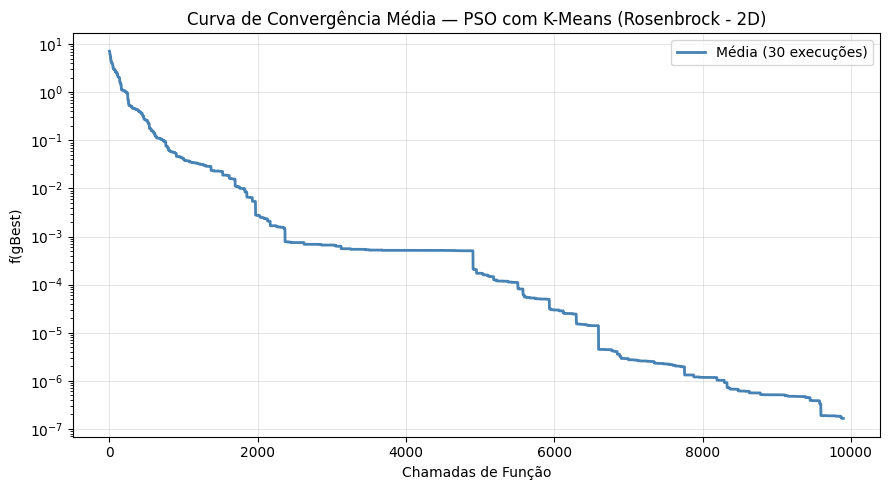

In [17]:
curva_convergencia_media(titulo= 'PSO com K-Means (Rosenbrock - 2D)',algoritmo=pso_kmeans)

Execução 10/30
Execução 20/30
Execução 30/30


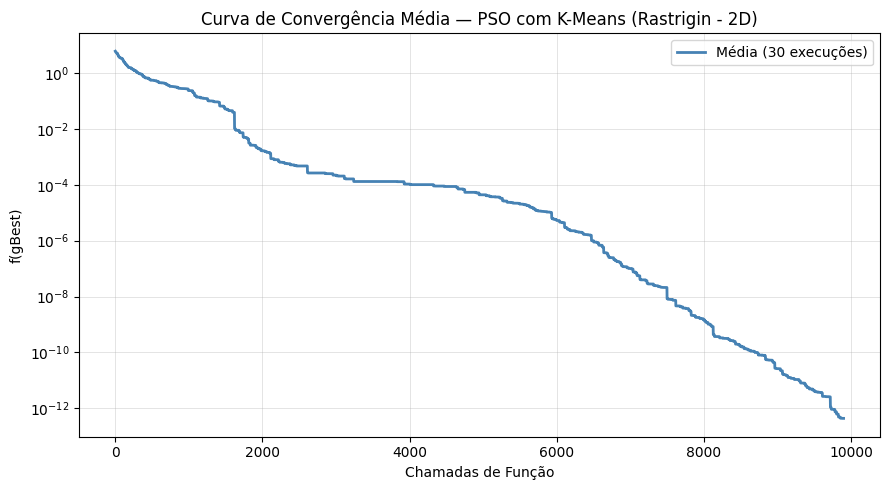

In [18]:
curva_convergencia_media(titulo= 'PSO com K-Means (Rastrigin - 2D)',algoritmo=pso_kmeans, problema=rastrigin, intervalo=[-5.12, 5.12], dimensao=2, parada=10000, n_execucoes=30)

### Comparação PSO Normal vs. PSO com K-Means

In [19]:
N_EXECUCOES = 30
historico_pso = []
historico_kmeans = []

problema = rosenbrock
intervalo = [-5, 10]

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")
    _, _, _, _, hist_pso = pso(
        tam_populacao=100,
        problema=problema,
        intervalo=intervalo,
        dimensao=2,
        parada=10000,
        history=True
    )
    _, _, _, _, hist_psok = pso_kmeans(
        tam_populacao=100,
        problema=problema,
        intervalo=intervalo,
        dimensao=2,
        parada=10000,
        history=True
    )
    historico_pso.append(hist_pso)
    historico_kmeans.append(hist_psok)

historico_pso = np.array(historico_pso)
historico_kmeans = np.array(historico_kmeans)

media_pso = np.mean(historico_pso, axis=0)
media_kmeans = np.mean(historico_kmeans, axis=0)
n_iteracoes = historico_pso.shape[1]
eixo_x = np.arange(n_iteracoes)



Execução 10/30
Execução 20/30
Execução 30/30


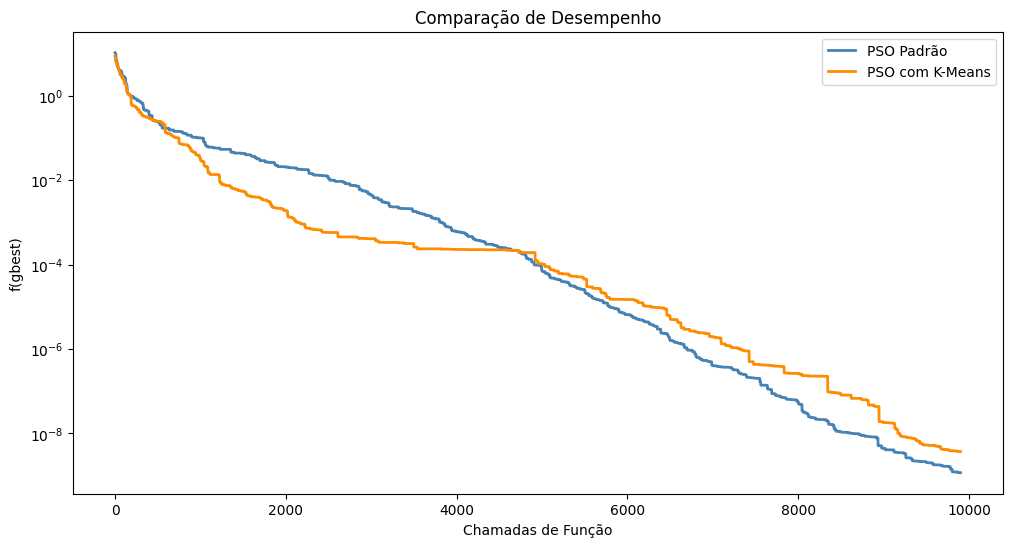

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(eixo_x, media_pso, color='steelblue', linewidth=2, label='PSO Padrão')
ax.plot(eixo_x, media_kmeans, color='darkorange', linewidth=2, label='PSO com K-Means')
ax.set_xlabel('Chamadas de Função')
ax.set_ylabel('f(gbest)')
ax.set_title('Comparação de Desempenho')
ax.set_yscale('log')
ax.legend()
plt.show()

## Pymooo


In [21]:
!pip install pymoo


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from pymoo.problems.single import Rosenbrock, Rastrigin
from pymoo.algorithms.soo.nonconvex.pso import PSO
from pymoo.optimize import minimize
from pymoo.termination import get_termination

pymoo_rosenbrock = Rosenbrock()
pymoo_rastrigin = Rastrigin()

pymoo_pso = PSO(pop_size=100)

res = minimize(pymoo_rosenbrock,
               pymoo_pso,
               termination=("n_eval", 10000),
               seed=1,
               verbose=False,
               save_history=True)

print(f"Best solution found: \nX = {res.X}\nF = {res.F}\nNumber of evaluations: {res.algorithm.evaluator.n_eval}")

Best solution found: 
X = [1.00004227 1.0000866 ]
F = [2.20835706e-09]
Number of evaluations: 10000


In [23]:
import matplotlib.pyplot as plt
N_EXECUCOES = 30
historicos_pymoo = []

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")
    res = minimize(pymoo_rosenbrock,
                   pymoo_pso,
                   termination=("n_eval", 10000),
                   seed=i,
                   verbose=False,
                   save_history=True)
    historicos_pymoo.append(np.array([e.opt[0].F for e in res.history]))

Execução 10/30
Execução 20/30
Execução 30/30


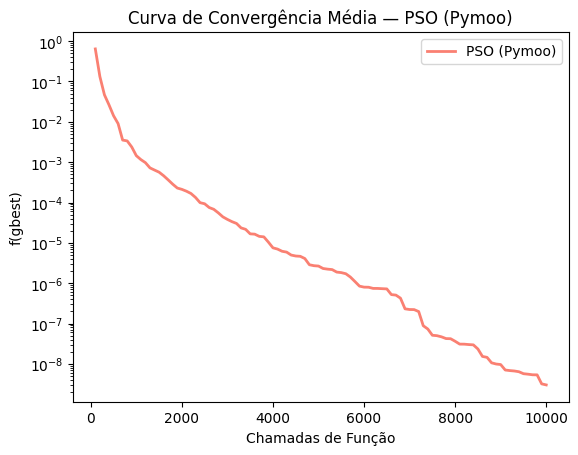

In [24]:
historicos_pymoo = np.array(historicos_pymoo)
media_pymoo = np.mean(historicos_pymoo, axis=0)
n_evals = np.array([e.evaluator.n_eval for e in res.history])
plt.xlabel('Chamadas de Função')
plt.ylabel('f(gbest)')
plt.title('Curva de Convergência Média — PSO (Pymoo)')
plt.plot(n_evals, media_pymoo, color='salmon', linewidth=2 , label='PSO (Pymoo)')
plt.yscale('log')
plt.legend()
plt.show()

## Pyswarms

In [25]:
!pip install pyswarms


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import plot_cost_history, plot_contour, plot_surface

options = {'c1': 1.5, 'c2': 1.5, 'w': np.random.uniform(0.4, 0.9)}
optimizer = ps.single.GlobalBestPSO(n_particles=100, dimensions=2, options=options, bounds=([-5, -5], [10, 10]))
best_fx, best_pos = optimizer.optimize(fx.rosenbrock, iters=10000)

2026-05-20 21:25:54,048 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6563965999075616}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:26:03,733 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]


In [27]:
N_EXECUCOES = 30
historico_pswarms = []

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")
    options = {'c1': 1.5, 'c2': 1.5, 'w': np.random.uniform(0.4, 0.9)}
    optimizer = ps.single.GlobalBestPSO(n_particles=100, dimensions=2, options=options, bounds=([-5, -5], [10, 10]))
    best_fx, best_pos = optimizer.optimize(fx.rosenbrock, iters=10000)
    historico_pswarms.append(optimizer.cost_history)

historico_pswarms = np.array(historico_pswarms)
media_pswarms = np.mean(historico_pswarms, axis=0)

2026-05-20 21:26:03,775 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6015997045597146}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:26:13,609 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-20 21:26:13,642 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6389255643194702}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:26:23,869 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-20 21:26:23,921 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6319687239122951}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:26:33,807 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best po

Execução 10/30


pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:27:52,817 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-20 21:27:52,840 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.40525592365273594}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:28:01,864 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-20 21:28:01,923 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.41430565200980785}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:28:11,150 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-20 21:28:11,171 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.43536

Execução 20/30


pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0      
2026-05-20 21:29:25,084 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-20 21:29:25,105 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.4060381447296255}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:29:34,057 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]
2026-05-20 21:29:34,093 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8843927888926578}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=3.99e-30
2026-05-20 21:29:44,975 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 3.993608332681372e-30, best pos: [1. 1.]
2026-05-20 21:29:45,012 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2'

Execução 30/30


pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:31:03,330 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1. 1.]


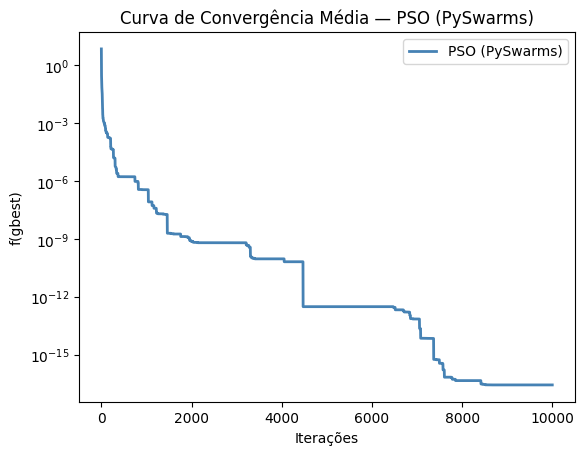

In [28]:
plt.xlabel('Iterações')
plt.ylabel('f(gbest)')
plt.title('Curva de Convergência Média — PSO (PySwarms)')
plt.plot(media_pswarms, color='steelblue', linewidth=2, label='PSO (PySwarms)')
plt.yscale('log')
plt.legend()
plt.show()

## Comparação entre as implementações

### Rosenbrock

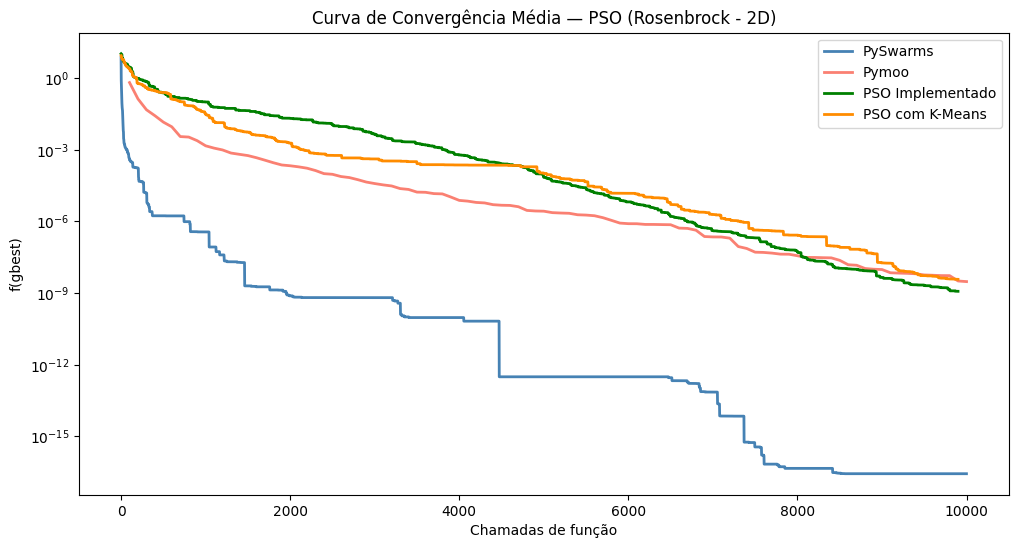

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlabel('Chamadas de função')
ax.set_ylabel('f(gbest)')
ax.set_title('Curva de Convergência Média — PSO (Rosenbrock - 2D)')
ax.plot(media_pswarms, color='steelblue', linewidth=2, label='PySwarms')
ax.plot(n_evals, media_pymoo, color='salmon', linewidth=2 , label='Pymoo')
ax.plot(media_pso, color='green', linewidth=2, label='PSO Implementado')
ax.plot(media_kmeans, color='darkorange', linewidth=2, label='PSO com K-Means')
plt.yscale('log')
plt.legend()
plt.show()

C:\Users\Pichau\AppData\Local\Temp\ipykernel_6204\4216257357.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, patch_artist=True)


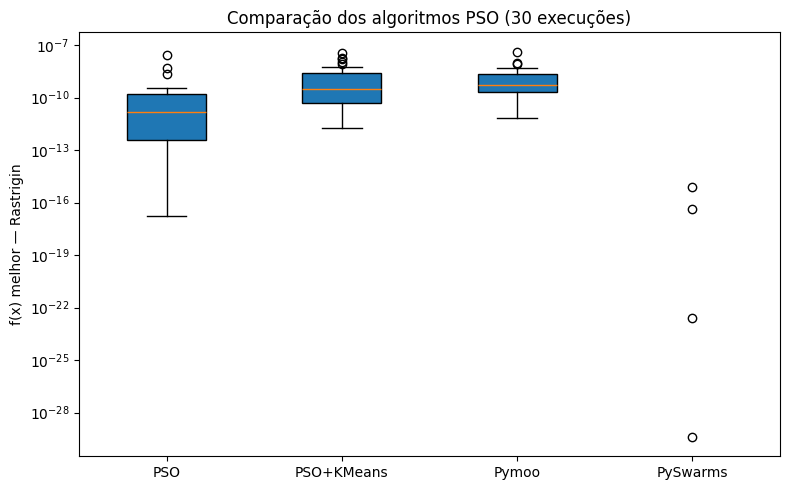

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Pega o valor final de cada execução (última iteração)
finais_pso       = historico_pso[:, -1]
finais_pso_kmeans= historico_kmeans[:, -1]
finais_pymoo     = historicos_pymoo[:, -1].flatten()
finais_pswarms   = historico_pswarms[:, -1]

dados = [finais_pso, finais_pso_kmeans, finais_pymoo, finais_pswarms]
labels = ['PSO', 'PSO+KMeans', 'Pymoo', 'PySwarms']

plt.figure(figsize=(8, 5))
plt.boxplot(dados, labels=labels, patch_artist=True)
plt.ylabel('f(x) melhor — Rastrigin')
plt.yscale('log')
plt.title('Comparação dos algoritmos PSO (30 execuções)')
plt.tight_layout()
plt.show()

### Rastringin

In [31]:
N_EXECUCOES = 30

problema = rastrigin
intervalo = [-5.12, 5.12]

historicos_pymoo = []
historicos_pswarms = []
historico_pso = []
historico_pso_kmeans = []

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")
    # PSO Implementado
    _, _, _, _, hist_pso = pso(
        tam_populacao=100,
        problema=problema,
        intervalo=intervalo,
        dimensao=2,
        parada=10000,
        history=True
    )
    historico_pso.append(hist_pso)

    # PSO com K-Means
    _, _, _, _, hist_psok = pso_kmeans(
        tam_populacao=100,
        problema=problema,
        intervalo=intervalo,
        dimensao=2,
        parada=10000,
        history=True
    )
    historico_pso_kmeans.append(hist_psok)

    # PSO do Pymoo
    res = minimize(pymoo_rastrigin,
                   pymoo_pso,
                   termination=("n_eval", 10000),
                   seed=i,
                   verbose=False,
                   save_history=True)
    historicos_pymoo.append(np.array([e.opt[0].F for e in res.history]))

    # PSO do PySwarms
    options = {'c1': 1.5, 'c2': 1.5, 'w': np.random.uniform(0.4, 0.9)}
    optimizer = ps.single.GlobalBestPSO(n_particles=100, dimensions=2, options=options, bounds=([-5.12, -5.12], [5.12, 5.12]))
    best_fx, best_pos = optimizer.optimize(fx.rastrigin, iters=10000)
    historicos_pswarms.append(optimizer.cost_history)

historico_pso = np.array(historico_pso)
historico_pso_kmeans = np.array(historico_pso_kmeans)
historicos_pymoo = np.array(historicos_pymoo)
historicos_pswarms = np.array(historicos_pswarms)

media_pso = np.mean(historico_pso, axis=0)
media_pso_kmeans = np.mean(historico_pso_kmeans, axis=0)
media_pymoo = np.mean(historicos_pymoo, axis=0)
media_pswarms = np.mean(historicos_pswarms, axis=0)
n_iteracoes = historico_pso.shape[1]
eixo_x = np.arange(n_iteracoes)




2026-05-20 21:31:08,063 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7170085102368373}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0     
2026-05-20 21:31:17,323 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1.11613893e-09 2.93060275e-09]
2026-05-20 21:31:20,427 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6742309381926808}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0    
2026-05-20 21:31:30,123 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [ 1.02660748e-09 -2.69777468e-09]
2026-05-20 21:31:33,401 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.44001395033122886}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-20 21:31:42,452 - pyswarms.single.global_best - INFO -

Execução 10/30


2026-05-20 21:33:01,450 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.655882727156745}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-20 21:33:11,151 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [2.97124206e-09 3.74635926e-10]
2026-05-20 21:33:14,810 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.5218695971424707}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-20 21:33:23,867 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [-3.01722921e-09  2.12156712e-10]
2026-05-20 21:33:27,183 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.49674390652354966}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-20 21:33:36,257 - pyswarms.single.global_best - INFO - Opt

Execução 20/30


2026-05-20 21:35:05,407 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8961094059703667}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0      
2026-05-20 21:35:16,404 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [ 2.04250138e-09 -4.02529435e-10]
2026-05-20 21:35:19,715 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.5696620152281754}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-20 21:35:28,656 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [1.53971082e-10 2.38790841e-09]
2026-05-20 21:35:32,022 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6611716689146521}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-20 21:35:40,907 - pyswarms.single.global_best - INFO - 

Execução 30/30


2026-05-20 21:37:11,216 - pyswarms.single.global_best - INFO - Optimize for 10000 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.6369804800883629}
pyswarms.single.global_best: 100%|██████████|10000/10000, best_cost=0   
2026-05-20 21:37:20,143 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0, best pos: [-1.36245848e-09  2.23360112e-09]


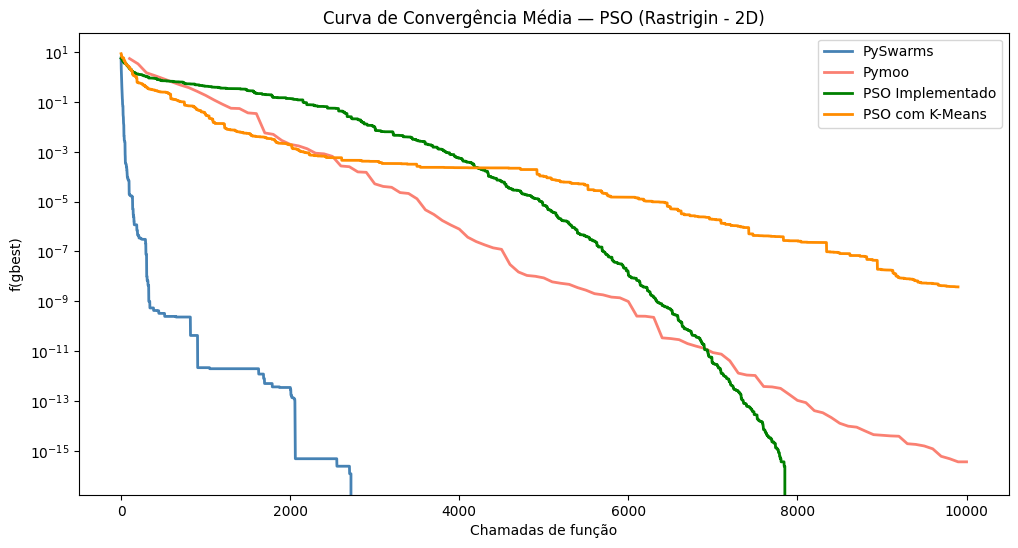

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlabel('Chamadas de função')
ax.set_ylabel('f(gbest)')
ax.set_title('Curva de Convergência Média — PSO (Rastrigin - 2D)')
ax.plot(media_pswarms, color='steelblue', linewidth=2, label='PySwarms')
ax.plot(n_evals, media_pymoo, color='salmon', linewidth=2 , label='Pymoo')
ax.plot(media_pso, color='green', linewidth=2, label='PSO Implementado')
ax.plot(media_kmeans, color='darkorange', linewidth=2, label='PSO com K-Means')
plt.yscale('log')
plt.legend()
plt.show()

C:\Users\Pichau\AppData\Local\Temp\ipykernel_6204\2245665484.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, patch_artist=True)


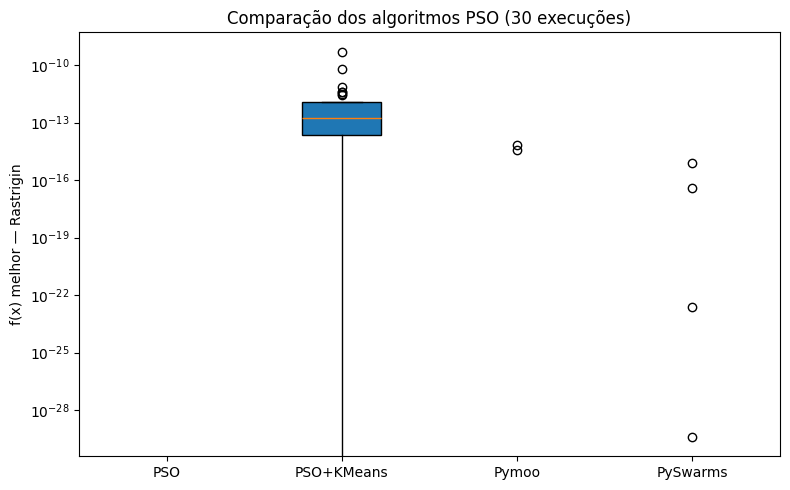

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Pega o valor final de cada execução (última iteração)
finais_pso       = historico_pso[:, -1]
finais_pso_kmeans= historico_pso_kmeans[:, -1]
finais_pymoo     = historicos_pymoo[:, -1].flatten()
finais_pswarms   = historico_pswarms[:, -1]

dados = [finais_pso, finais_pso_kmeans, finais_pymoo, finais_pswarms]
labels = ['PSO', 'PSO+KMeans', 'Pymoo', 'PySwarms']

plt.figure(figsize=(8, 5))
plt.boxplot(dados, labels=labels, patch_artist=True)
plt.ylabel('f(x) melhor — Rastrigin')
plt.yscale('log')
plt.title('Comparação dos algoritmos PSO (30 execuções)')
plt.tight_layout()
plt.show()

## Circuito Elétrico

In [97]:
# [2] Função custo (ou aptidão)
# cost_function: função de custo
#   parâmetro:
#     I: correntes (posições das partículas)
#   retorno: custos (numpy.ndarray com custo calculado para cada partícula)
def cost_function(I):

    # parâmetros fixos
    U = 10
    R = 100
    I_s = 9.4e-12
    v_t = 25.85e-3

    # normalizar entrada
    I = np.array(I)

    # caso escalar
    if I.ndim == 0:
        I0 = float(I)
        I_safe = max(abs(I0), 1e-300)
        return abs(U - v_t * np.log(I_safe / I_s) - R * I0)

    # caso 1D: pode ser uma partícula (dim=1) ou vetor de variáveis
    if I.ndim == 1:
        if I.size == 1:
            I0 = float(I[0])
            I_safe = max(abs(I0), 1e-300)
            return abs(U - v_t * np.log(I_safe / I_s) - R * I0)
        # se for vetor multi-dimensional, usamos a primeira componente como corrente
        I0 = I[0]
        I_safe = max(abs(I0), 1e-300)
        return abs(U - v_t * np.log(I_safe / I_s) - R * I0)

    # caso 2D: vetor de partículas (n_part, n_var) -> retorna vetor de custos
    if I.ndim == 2:
        I0 = I[:, 0]
        I_safe = np.clip(np.abs(I0), 1e-300, None)
        c = np.abs(U - v_t * np.log(I_safe / I_s) - R * I0)
        return c

    raise ValueError('Formato de entrada de I não suportado')

print('Função de custo carregada...')

Função de custo carregada...


#### PySwarms

In [98]:
#[3] Hiperparâmetros e Otimização

# hiperparâmetros
options = {'c1': 0.5, 'c2': 0.3, 'w':0.3}

# instanciação do PSO
optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=1, options=options)

# execução da otimização
cost, pos = optimizer.optimize(cost_function, iters=30)

print('\nCorrente (I) = %.3f A' % pos[0])
print('Custo = ', cost)

2026-05-20 22:05:45,575 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.3}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=3.5e-7 
2026-05-20 22:05:45,595 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 3.495001745790205e-07, best pos: [0.09404768]



Corrente (I) = 0.094 A
Custo =  3.495001745790205e-07


#### Pymoo

In [99]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.pso import PSO
from pymoo.optimize import minimize

class DiodeProblem(Problem):
    def __init__(self):
        # 1 variável (corrente I), com limites físicos razoáveis
        super().__init__(
            n_var=1,
            n_obj=1,
            n_ieq_constr=0,
            xl=np.array([1e-12]),   # limite inferior de I (A)
            xu=np.array([0.1]),     # limite superior de I (A)
        )

    def _evaluate(self, X, out, *args, **kwargs):
        # X.shape == (n_partículas, n_var)  →  igual ao seu parâmetro I
        U   = 10
        R   = 100
        I_s = 9.4e-12
        v_t = 25.85e-3

        custo = np.abs(U - v_t * np.log(np.abs(X[:, 0] / I_s)) - R * X[:, 0])
        out["F"] = custo.reshape(-1, 1)   # shape obrigatório: (n_part, n_obj)


problem   = DiodeProblem()
algorithm = PSO(pop_size=10)

res = minimize(
    problem,
    algorithm,
    termination=("n_gen", 30),
    verbose=False,
)

print(f"\nCorrente : I = {res.X[0]} A")
print(f"Custo mínimo               : {res.F[0]}")


Corrente : I = 0.09404766849837798 A
Custo mínimo               : 1.7981088848983973e-06


#### PSO Implementado

In [104]:
pso(tam_populacao=10, parada=300, problema=cost_function, intervalo=[1e-12, 0.1], dimensao=1)

Particula= [[0.09404769]] - f(x*) = 2.0625741115054552e-09
Chamadas de Função = 300


#### PSO com Kmeans

In [103]:
pso_kmeans(tam_populacao=10, parada=300, problema=cost_function, intervalo=[1e-12, 0.1], dimensao=1)

Partícula = [0.09404732]
f(x*)     = 3.704509209967455e-05
Chamadas  = 300


#### Curva de Convergência média

Execução 10/30
Execução 20/30
Execução 30/30


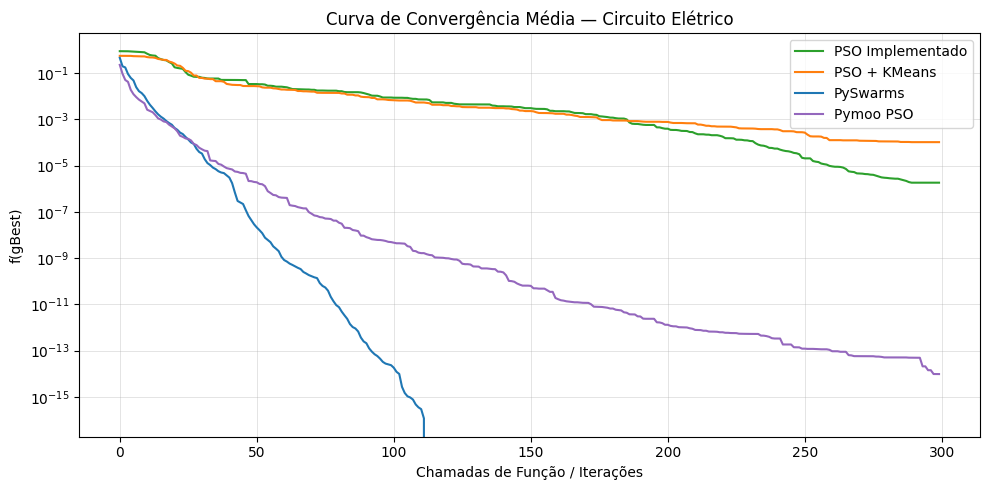

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pyswarms as ps

from pymoo.algorithms.soo.nonconvex.pso import PSO as PymooPSO
from pymoo.optimize import minimize

# Curva de Convergência média — Circuito Elétrico (PSO implementado vs PSO+KMeans vs PySwarms vs Pymoo PSO)
N_EXECUCOES = 30
PARADA = 300

historicos_pso = []
historicos_kmeans = []
historicos_pswarms = []
historicos_pymoo = []

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")

    # PSO implementado
    _, _, _, _, hist_pso = pso(tam_populacao=10, parada=PARADA, problema=cost_function, intervalo=[1e-12, 0.1], dimensao=1, history=True)

    # PSO + KMeans
    _, _, _, _, hist_k = pso_kmeans(tam_populacao=10, parada=PARADA, problema=cost_function, intervalo=[1e-12, 0.1], dimensao=1, history=True)

    # PySwarms
    options = {'c1': 0.5, 'c2': 0.3, 'w': 0.3}
    optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=1, options=options, bounds=([1e-12], [0.1]))
    _ = optimizer.optimize(cost_function, iters=PARADA, verbose=False)
    hist_ps = np.array(optimizer.cost_history)

    # Pymoo PSO
    problem = DiodeProblem()
    algorithm = PymooPSO(pop_size=10)
    res = minimize(problem, algorithm, termination=("n_gen", PARADA), seed=i, verbose=False, save_history=True)
    hist_pym = np.array([e.opt[0].F.ravel()[0] for e in res.history])

    # função auxiliar para ajustar tamanho
    def pad_hist(h, L):
        h = np.array(h)
        if h.size == 0:
            return np.full(L, np.nan)
        if h.size < L:
            return np.concatenate([h, np.full(L - h.size, h[-1])])
        return h[:L]

    historicos_pso.append(pad_hist(hist_pso, PARADA))
    historicos_kmeans.append(pad_hist(hist_k, PARADA))
    historicos_pswarms.append(pad_hist(hist_ps, PARADA))
    historicos_pymoo.append(pad_hist(hist_pym, PARADA))

# converter para arrays
historicos_pso = np.array(historicos_pso)
historicos_kmeans = np.array(historicos_kmeans)
historicos_pswarms = np.array(historicos_pswarms)
historicos_pymoo = np.array(historicos_pymoo)

# calcular média
media_pso = np.nanmean(historicos_pso, axis=0)
media_kmeans = np.nanmean(historicos_kmeans, axis=0)
media_pswarms = np.nanmean(historicos_pswarms, axis=0)
media_pymoo = np.nanmean(historicos_pymoo, axis=0)

it = np.arange(PARADA)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(it, media_pso, label='PSO Implementado', color='tab:green')
ax.plot(it, media_kmeans, label='PSO + KMeans', color='tab:orange')
ax.plot(it, media_pswarms, label='PySwarms', color='tab:blue')
ax.plot(it, media_pymoo, label='Pymoo PSO', color='tab:purple')
ax.set_yscale('log')
ax.set_xlabel('Chamadas de Função / Iterações')
ax.set_ylabel('f(gBest)')
ax.set_title('Curva de Convergência Média — Circuito Elétrico')
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.6)
plt.tight_layout()
plt.show()

#### Boxplot

Execução 10/30
Execução 20/30
Execução 30/30


C:\Users\Pichau\AppData\Local\Temp\ipykernel_6204\3072721654.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=labels, patch_artist=True)


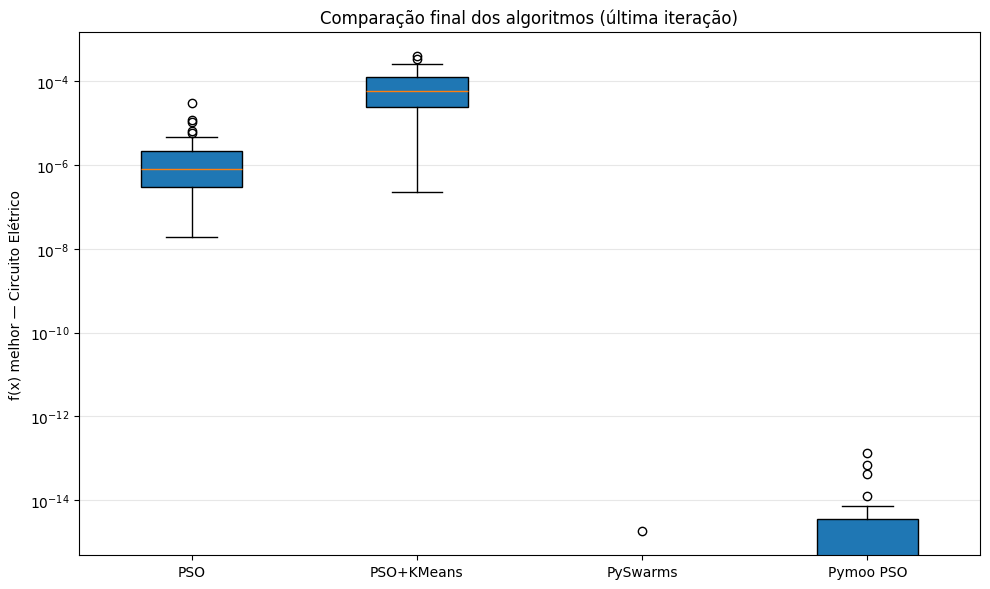

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import pyswarms as ps
from pymoo.algorithms.soo.nonconvex.pso import PSO as PymooPSO
from pymoo.optimize import minimize

# Boxplot final dos melhores valores (última iteração) — Circuito Elétrico
N_EXECUCOES = 30
PARADA = 300

finais_pso = []
finais_kmeans = []
finais_pswarms = []
finais_pymoo = []

for i in range(N_EXECUCOES):
    if (i+1) % 10 == 0:
        print(f"Execução {i+1}/{N_EXECUCOES}")

    # PSO implementado
    _, _, gbest_val_pso, _, _ = pso(tam_populacao=10, parada=PARADA, problema=cost_function, intervalo=[1e-12, 0.1], dimensao=1, history=True)

    # PSO + KMeans
    _, _, gbest_val_k, _, _ = pso_kmeans(tam_populacao=10, parada=PARADA, problema=cost_function, intervalo=[1e-12, 0.1], dimensao=1, history=True)

    # PySwarms
    options = {'c1': 0.5, 'c2': 0.3, 'w': 0.3}
    optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=1, options=options, bounds=([1e-12], [0.1]))
    _ = optimizer.optimize(cost_function, iters=PARADA, verbose=False)
    gbest_val_ps = optimizer.cost_history[-1] if len(optimizer.cost_history) > 0 else np.nan

    # Pymoo PSO
    problem = DiodeProblem()
    algorithm = PymooPSO(pop_size=10)
    res = minimize(problem, algorithm, termination=("n_gen", PARADA), seed=i, verbose=False)
    gbest_val_pm = float(np.atleast_1d(res.F).ravel()[0])

    finais_pso.append(gbest_val_pso)
    finais_kmeans.append(gbest_val_k)
    finais_pswarms.append(gbest_val_ps)
    finais_pymoo.append(gbest_val_pm)

# preparar dados e plot
dados = [finais_pso, finais_kmeans, finais_pswarms, finais_pymoo]
labels = ['PSO', 'PSO+KMeans', 'PySwarms', 'Pymoo PSO']

plt.figure(figsize=(10, 6))
plt.boxplot(dados, labels=labels, patch_artist=True)
plt.yscale('log')
plt.ylabel('f(x) melhor — Circuito Elétrico')
plt.title('Comparação final dos algoritmos (última iteração)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()